Score-based Generative Modeling 

In [29]:
import sys
from torch.utils.data.dataloader import DataLoader
import torch
from torch import nn
from torch import tensor
import torch.nn.functional as F
import matplotlib.pyplot as plt
sys.path.append("../..")
from datasets.gaussian_spiral import GaussianSpiralDataset, plot_gaussian_spiral
from datasets.digits import Digits, plot_digits

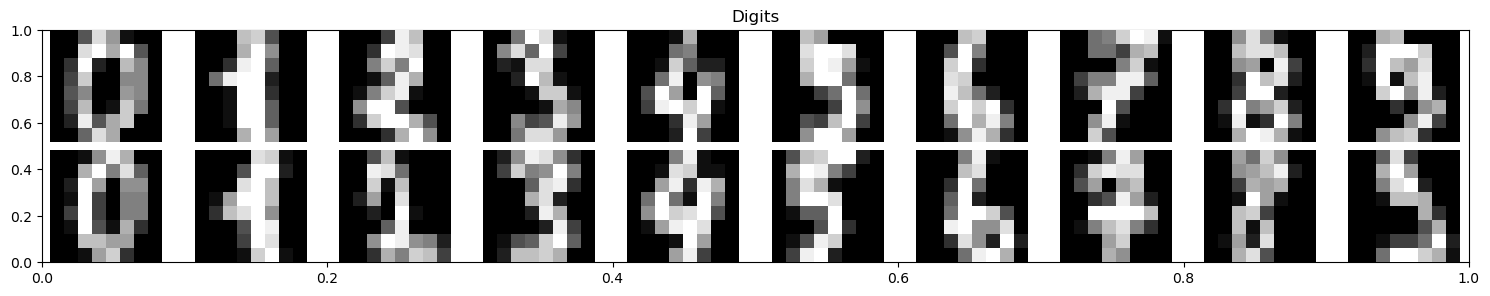

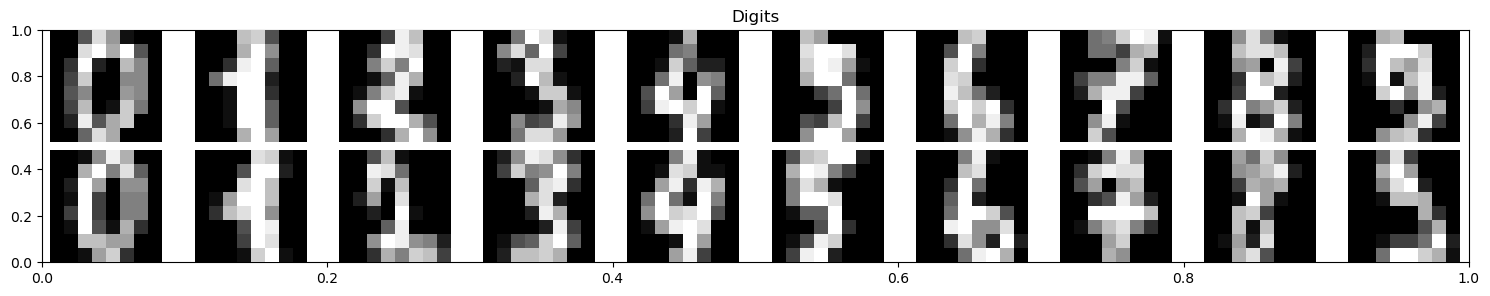

In [30]:
# n=1000
# train_dataset = GaussianSpiralDataset(n=n, rotations=2, var=0.2, seed=None, mode="train", mean=None, std=None)
# train_dataloader = DataLoader(dataset=train_dataset, batch_size=n)
# plot_gaussian_spiral(*next(iter(train_dataloader)))

n=20
train_dataset = Digits(mode="train", normalized=True)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=n)
plot_digits(next(iter(train_dataloader)))


### Score Network

In [31]:
def sigmas_geometric(t, sigma_min=0.0, sigma_max=1.0, type='ncsn'):
    # uniform in [0,1]
    sigma_min, sigma_max = tensor(sigma_min), tensor(sigma_max)
    t = tensor(t)

    if type == 'ncsn':        
        log_sigma = torch.log(sigma_min) + t * (torch.log(sigma_max) - torch.log(sigma_min))
        return torch.exp(log_sigma)
    if type == 'VE-SDE':
        assert sigma_min==0.0
        return torch.sqrt( (1./(2.* torch.log(sigma_max))) * (sigma_max**(2*t) - 1.) )
    if type == 'lin':
        return sigma_min + (sigma_max - sigma_min) * t
    


class ScoreNet(nn.Module):

    def __init__(self, dim, hidden_dims=[8,8]):
        super().__init__()

        dims = [dim]+hidden_dims
        self.time_embedding = nn.Sequential(nn.Linear(1, dim), nn.Tanh())
        
        layers = []
        for in_d, out_d in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(in_d, out_d))
            layers.append(nn.ReLU())
            
        self.layers = nn.Sequential(*layers)

        self.out = nn.Linear(hidden_dims[-1], dim)
        
    def forward(self, x, sigmas):

        x = x + self.time_embedding(sigmas)
        x = self.layers(x)
        x = self.out(x)

        return x


class ScoreNetT(nn.Module):
    def __init__(self, dim, hidden_dims=[32,32]):
        super().__init__()
        dims = [dim] + hidden_dims

        # one embedding per layer input
        self.t_embs = nn.ModuleList([
            nn.Sequential(nn.Linear(1, in_d), nn.Tanh())
            for in_d in dims
        ])

        self.layers = nn.ModuleList([
            nn.Linear(in_d, out_d)
            for in_d, out_d in zip(dims, dims[1:])
        ])
        self.out = nn.Linear(hidden_dims[-1], dim)

    def forward(self, x, sigma):
        for t_emb, lin in zip(self.t_embs, self.layers):
            # inject σ at each layer
            x = F.relu(lin(x + t_emb(sigma)))
        return self.out(x)
    
class ScoreNetConv(nn.Module):
    def __init__(self, in_channels, hidden_channels=[32, 32]):
        super().__init__()
        channels = [in_channels] + hidden_channels

        self.t_embs = nn.ModuleList([
            nn.Sequential(nn.Linear(1, ch), nn.Tanh())
            for ch in channels
        ])

        self.convs = nn.ModuleList([
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
            for in_ch, out_ch in zip(channels, channels[1:])
        ])
        self.out = nn.Conv2d(hidden_channels[-1], in_channels, kernel_size=3, padding=1)

    def forward(self, x, sigma):
        
        assert len(x.shape) == 4, f"Expecting [B,C,H,W], but got len(x.shape)={len(x.shape)}"

        for t_emb, conv in zip(self.t_embs, self.convs):
            emb = t_emb(sigma.view(-1, 1)).view(-1,conv.in_channels,1,1)
            x = F.relu(conv(x + emb))
        return self.out(x)
    

class FiLMLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        # map time t→ [γ, β] of size 2*out_features
        self.film   = nn.Linear(1, 2 * out_features)

    def forward(self, x, t):
        # x: (B, in_features), t: (B,) or (B,1)
        h = self.linear(x)
        t = t.view(-1, 1)              # ensure shape (B,1)
        gamma, beta = self.film(t).chunk(2, dim=-1)
        return gamma * h + beta

class ScoreNetFiLM(nn.Module):

    def __init__(self, dim, hidden_dims=[8,8]):
        super().__init__()

        dims = [dim]+hidden_dims

        self.time_embedding = nn.Sequential(nn.Linear(1, dim), nn.Tanh())
        
        self.layers = nn.ModuleList([
            FiLMLinear(in_d, out_d)
            for in_d, out_d in zip(dims[:-1], dims[1:])
        ])

        self.out = nn.Linear(hidden_dims[-1], dim)
        
    def forward(self, x, sigmas):

        for layer in self.layers:
            x = F.relu(layer(x, sigmas))
        return self.out(x)


### Plot Score Function of the Dataset

/tmp/ipykernel_1683831/1833020302.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = tensor(t)


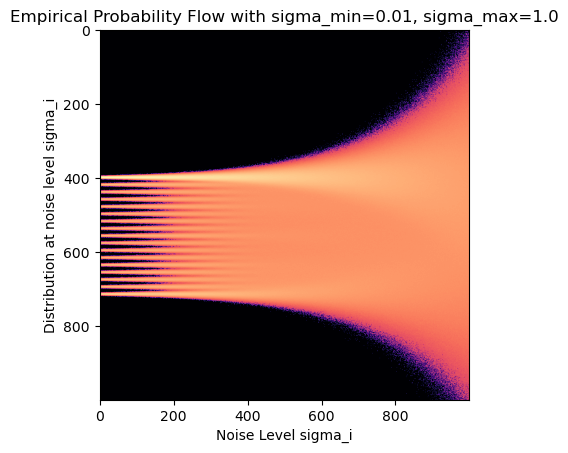

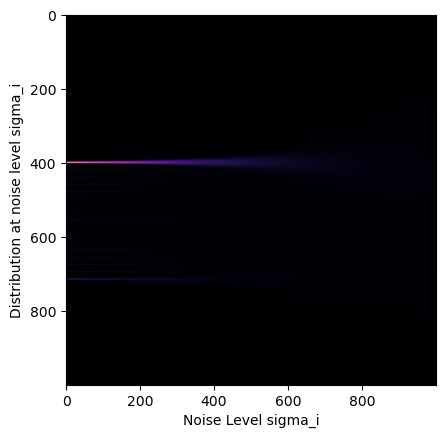

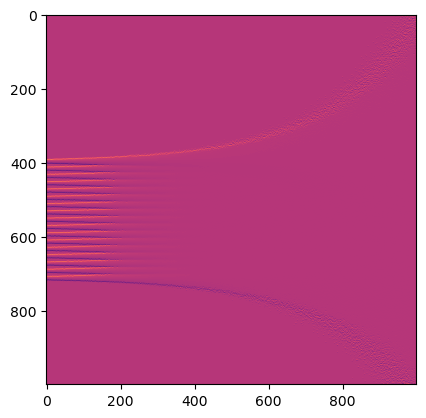

In [48]:
import numpy as np
import scipy
import random 

torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

class FastAntialiasing:
    '''
    If too slow for large Batches and Sequence lengths (because of loop), 
    create tiled version. For this, the mode 'constant' must be used and edge-
    handling needs to be implemented using a norm-array that the filter result
    is normalized with. This way, we could create one norm array that we 
    repeat along e.g. [B,T] s.t. we obtain a big [B*H, T*W] norm array.
    Then we padd inputs s.t. the filter doesn't transcend samples & timesteps, 
    then we stack padded inputs [B,T,H(padded),W(padded)] --> [B*H(padded), T*W(padded)],
    apply the gaussian filter, remove the pads, restack to [B,T,H,W]
    and devide by the norm array.
    '''
    def __init__(self, sigma=0.5):
        self.sigma = sigma

    def __call__(self, batch):
        # batch: (B, T or C, H, W)
        batch_np = batch.cpu().numpy()
        blurred = np.empty_like(batch_np)

        for i in range(batch_np.shape[0]):
            for j in range(batch_np.shape[1]):
                frame = batch_np[i, j]
                blurred_frame = scipy.ndimage.gaussian_filter(frame, sigma=self.sigma, mode='reflect')
                blurred[i, j] = blurred_frame

        return torch.from_numpy(blurred).to(batch.device)   

# transform = GaussianBlur(kernel_size=3, sigma=0.5) # extremely slow
# transform = FastAntialiasing(sigma=1.8) # equivalent to above GaussianBlur with sigma=0.5
train_dataset = Digits(mode="train", normalized=True) #, transforms=transform)
train_dataloader = DataLoader(train_dataset, batch_size=len(train_dataset))

x = next(iter(train_dataloader))
x = x.flatten()

n_noise_levels = 1000
t = torch.linspace(0,1,n_noise_levels)
sigma_min, sigma_max = 0.01, 1.0
sigmas = sigmas_geometric(t, sigma_min=sigma_min,sigma_max=sigma_max, type="ncsn")
noise = torch.randn((x.shape[0], n_noise_levels))

# cumulative_noise = torch.cumsum(noise * sigmas[None,:], dim=1)
sigma_weighted_noise = noise * sigmas[None,:]
x_full_noise = x+sigma_weighted_noise[:,-1]
hist_min, hist_max = x_full_noise.min(), x_full_noise.max()
border = max(abs(hist_min), abs(hist_max))
bins = torch.linspace(-border, border, 1024)

def plot_histograms_for_noise_levels():
    noise_indices = list(range(99, n_noise_levels, 100))
    cmap   = plt.get_cmap('tab10')
    colors = cmap(np.linspace(0, 1, len(noise_indices)))
    plt.figure()

    for color, nl in zip(colors, noise_indices):
        
        x_noisy     = x + sigma_weighted_noise[:, nl]
        hist, edges = torch.histogram(x_noisy, bins=bins)

        hist_np  = hist.detach().cpu().numpy()
        edges_np = edges.detach().cpu().numpy()
        widths   = np.diff(edges_np)

        plt.bar(edges_np[:-1], hist_np, width=widths, align='edge', color=color, alpha=0.5, label=f'nl={nl}')

    plt.xlabel('x value')
    plt.ylabel('Count')
    plt.title('Overlayed Histograms at Different Noise Levels')
    plt.legend(title='Noise index')
    plt.tight_layout()
    plt.show()
    plt.close()

# plot_histograms_for_noise_levels()

def plot_log_px(x, cumulative_noise, nbins=1000):

    x_noisy_2d = x[:,None] + cumulative_noise
    H,W = x_noisy_2d.shape
    col_idx = np.repeat(np.arange(W)[None, :], H, axis=0)

    min_val, max_val = x_noisy_2d.min(), x_noisy_2d.max()

    cutoff = 0.7
    pixel_edges = np.linspace(cutoff * min_val, cutoff * max_val, nbins+1)

    hist2d, xedges, yedges = np.histogram2d(
        col_idx.ravel(),
        x_noisy_2d.ravel(),
        bins=[np.arange(W+1), pixel_edges],
        range=None
    )

    image = hist2d.T
    # log_image = np.log(image)
    log_image = np.log(image+1e-5)
    plt.figure()
    plt.imshow(log_image, cmap="magma")
    plt.xlabel('Noise Level sigma_i')
    plt.ylabel('Distribution at noise level sigma_i')
    plt.title(f'Empirical Probability Flow with sigma_min={sigma_min}, sigma_max={sigma_max}')
    plt.show()

    plt.figure()
    plt.imshow(image, cmap="magma")
    plt.xlabel('Noise Level sigma_i')
    plt.ylabel('Distribution at noise level sigma_i')
    plt.show()

    score = np.diff(log_image, axis=0)
    plt.figure()
    plt.imshow(score, cmap="magma")
    plt.show()


plot_log_px(x, sigma_weighted_noise)
# TODO: Plot score function and and histogram


### Training and Validation Loops

In [33]:
def train_one_epoch(model, optimizer, dataloader, sigma_min, sigma_max, var_schedule, device):

    avg_loss = 0.0
    model.train()

    # for _, (x, _) in enumerate(dataloader):
    for _, x in enumerate(dataloader):
        # x.shape = [B,C or D, (optionally) H, W]

        # add noise
        sigmas =  sigmas_geometric(torch.rand([x.shape[0]] +[1]*len(x.shape[1:])), sigma_min, sigma_max, var_schedule).float()
        # sigmas =  sigmas_geometric(torch.rand((1,))* torch.ones(x.shape[0],1), sigma_min, sigma_max).float()
        # first overfit on single batch and single noise level
        # sigmas = sigmas_geometric(torch.ones(size=(batch_size,1)), sigma_min, sigma_max).float()

        noise = torch.randn_like(x)
        # noise = seeded_noise
        x_noisy = x + noise * sigmas

        sigmas, x_noisy, x = sigmas.to(device), x_noisy.to(device), x.to(device)
        nc_score = model(x_noisy, sigmas)

        denoising_loss = 0.5 * (nc_score + (x_noisy-x)/sigmas**2 )**2
        # unified loss by Song
        loss = (sigmas**2 * denoising_loss).mean() #+ model.parameters() # [B,1]*[B,D]--> [B,D]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item()
            
    return avg_loss / len(dataloader)

def validate(model, dataloader, epoch, sigma_min, sigma_max, var_schedule, device, plot_samples=None):

    # Disable gradient computation and reduce memory consumption.
    val_loss = 0.0
    model.eval()
    with torch.no_grad():

        # for x,_ in dataloader:
        for x in dataloader:

            sigmas = sigmas_geometric(torch.rand([x.shape[0]] +[1]*len(x.shape[1:])), sigma_min, sigma_max, var_schedule).float()
            noise = torch.randn_like(x)

            x_noisy = x + noise * sigmas

            if epoch == 0:
                plot_samples = x.shape[0] if plot_samples is None else plot_samples
                # plot_gaussian_spiral(x, t)
                # plot_gaussian_spiral(noise*sigmas)
                # plot_gaussian_spiral(x_noisy)
                
                plot_digits(x[:plot_samples], title="Raw Samples")
                plot_digits(noise[:plot_samples]*sigmas[:plot_samples], title="Noise")
                plot_digits(x_noisy[:plot_samples], title="Raw Samples with added Noise")

            sigmas, x_noisy, x = sigmas.to(device), x_noisy.to(device), x.to(device)
            nc_score = model(x_noisy, sigmas)

            denoising_loss = 0.5 * (nc_score + (x_noisy-x)/sigmas**2)**2
            # unified loss by Song
            val_loss += (sigmas**2 * denoising_loss).mean()

        return val_loss / len(dataloader)




### Training

NumParams: 150531
Epoch 0, training loss: 0.4917121430238088


/tmp/ipykernel_1683831/1833020302.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = tensor(t)


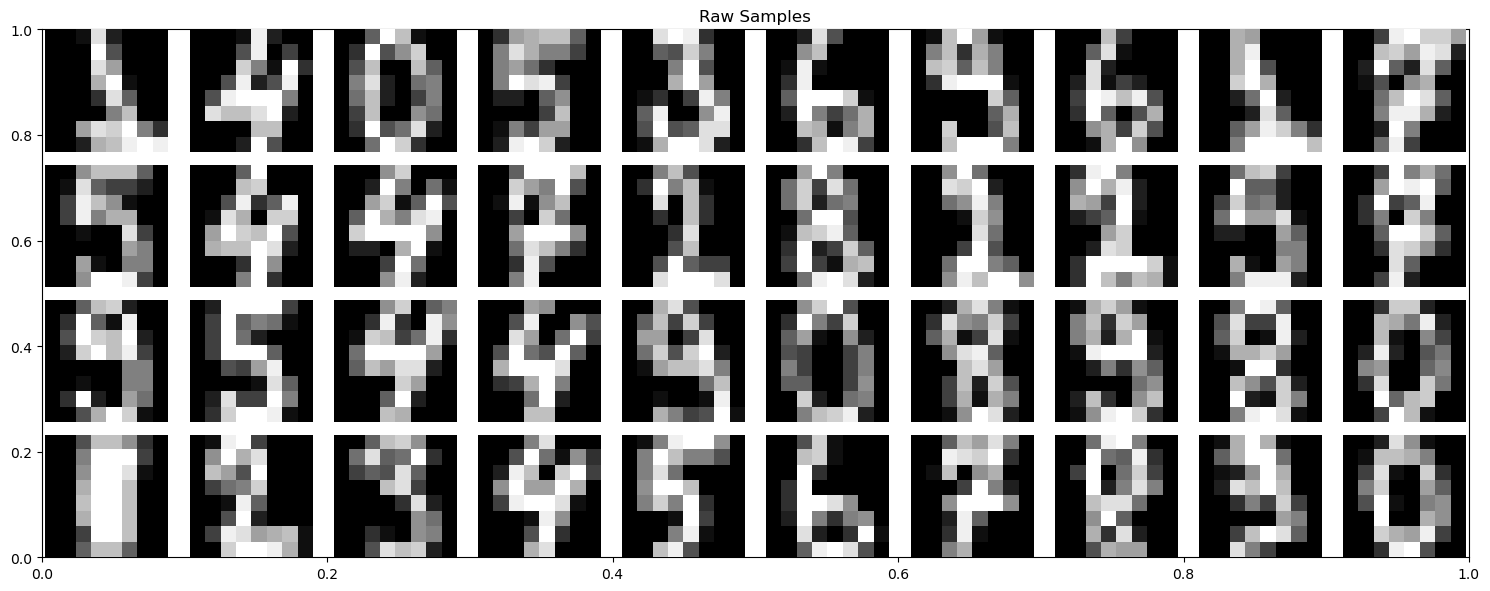

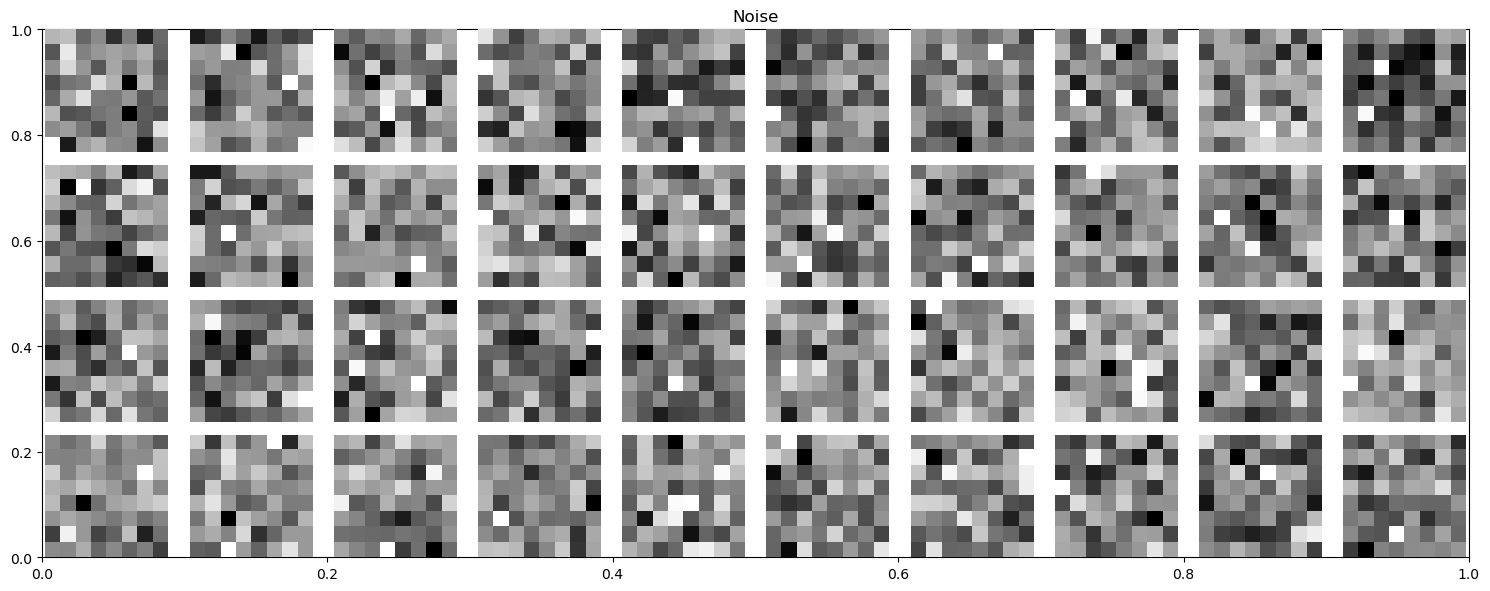

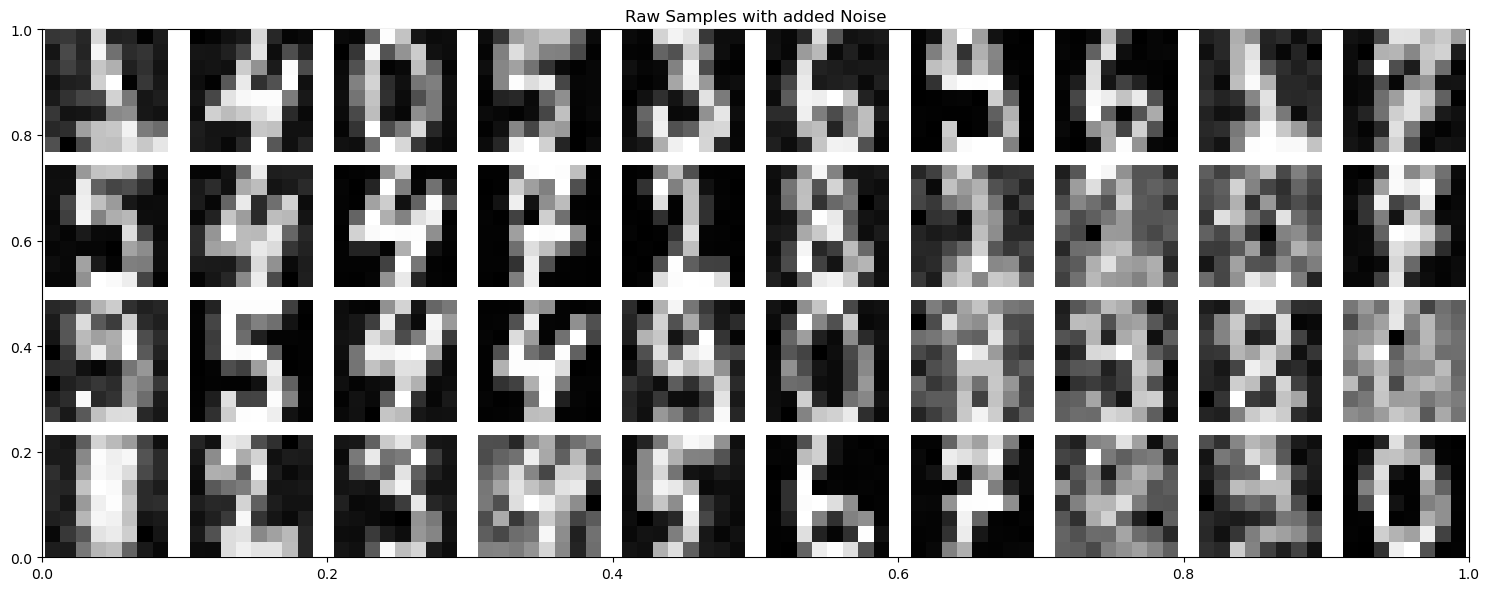

Epoch 0, training loss: 0.4917121430238088, validation loss: 0.49203822016716003
Epoch 1, training loss: 0.4949852724870046
Epoch 1, training loss: 0.4949852724870046, validation loss: 0.49338796734809875
Epoch 2, training loss: 0.5001315077145895
Epoch 2, training loss: 0.5001315077145895, validation loss: 0.5018337368965149
Epoch 3, training loss: 0.4943796694278717
Epoch 3, training loss: 0.4943796694278717, validation loss: 0.49773627519607544
Epoch 4, training loss: 0.49285516142845154
Epoch 4, training loss: 0.49285516142845154, validation loss: 0.4882275462150574
Epoch 5, training loss: 0.49061131477355957
Epoch 5, training loss: 0.49061131477355957, validation loss: 0.49218544363975525
Epoch 6, training loss: 0.4877813359101613
Epoch 6, training loss: 0.4877813359101613, validation loss: 0.49063780903816223
Epoch 7, training loss: 0.48969196279843646
Epoch 7, training loss: 0.48969196279843646, validation loss: 0.48921847343444824
Epoch 8, training loss: 0.48649075627326965
Epo

In [36]:
max_epochs = 1000
batch_size = 256
patience = 20

device = 0

var_schedule = 'ncsn'
sigma_min = 0.01
sigma_max = 1.0

learning_rate = 2e-5
spiral_var = 0.1
plot_samples = 40


# train_dataset = GaussianSpiralDataset(n=10000, rotations=2, var=spiral_var, seed=42, mode="train")
# train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, drop_last=True)
# val_dataset = GaussianSpiralDataset(n=2000, rotations=2, var=spiral_var, seed=43, mode="val", mean=train_dataset.get_mean(), std=train_dataset.get_std())
# val_dataloader = DataLoader(dataset=val_dataset, batch_size=len(val_dataset))

train_dataset = Digits(mode="train", normalized=True)
val_dataset = Digits(mode="val", normalized=True)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=len(val_dataset))


# ncsm = ScoreNetT(dim=2, hidden_dims=[32,32])
# ncsm = ScoreNetFiLM(dim=2, hidden_dims=[32,32])
ncsm = ScoreNetConv(in_channels=1, hidden_channels=[128,128])
ncsm = ncsm.to(device)

print(f"NumParams: {sum([p.numel() for p in ncsm.parameters()])}")

optimizer = torch.optim.AdamW(ncsm.parameters(), lr=learning_rate)
patience_count = 0
best_val_loss = torch.inf

for epoch in range(max_epochs):

    train_loss = train_one_epoch(ncsm, optimizer, train_dataloader, sigma_min, sigma_max, var_schedule, device)
    print(f"Epoch {epoch}, training loss: {train_loss}")

    val_loss = validate(ncsm, val_dataloader, epoch, sigma_min, sigma_max, var_schedule, device, plot_samples=plot_samples)
    print(f"Epoch {epoch}, training loss: {train_loss}, validation loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0
        torch.save(ncsm, 'ncsm.ckpt')
    else:
        patience_count += 1

    if patience_count >= patience:
        print(f"No improvement in {patience} epochs, stopping.")
        break

### Plot the Score Function (at least the marginals if multidimensional)

Plot the noise conditioned score function 

In [ ]:
train_dataset = Digits(mode="train", normalized=True) #, transforms=transform)
train_dataloader = DataLoader(train_dataset, batch_size=len(train_dataset))

x = next(iter(train_dataloader))
x = x.flatten()

n_noise_levels = 1000
t = torch.linspace(0,1,n_noise_levels)
sigma_min, sigma_max = 0.01, 1.0
sigmas = sigmas_geometric(t, sigma_min=sigma_min,sigma_max=sigma_max, type="ncsn")
noise = torch.randn((x.shape[0], n_noise_levels))

# cumulative_noise = torch.cumsum(noise * sigmas[None,:], dim=1)
sigma_weighted_noise = noise * sigmas[None,:]
x_full_noise = x+sigma_weighted_noise[:,-1]
hist_min, hist_max = x_full_noise.min(), x_full_noise.max()
border = max(abs(hist_min), abs(hist_max))
bins = torch.linspace(-border, border, 1024)

ncsm = torch.load("ncsm.ckpt", map_location="cuda:0")
ncsm.eval()

# TODO: 
# 1) Do inference on full dataset batch with every noise level: For i in enumerate(sigma_geometric(range(0,1000))) --> score_model(x_batch + noise[:,i], sigma)
# 2) Compute 1D marginals of every prediction? Do we need to compute a distribution to get the score first? Do we then have to integrate all the values up and  


# TODO: Do inference on test dataset batch as well? --> maybe that is more important

torch.Size([1000, 1, 8, 8])

### Sampling

/tmp/ipykernel_1683831/1833020302.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = tensor(t)
/tmp/ipykernel_1683831/4278065524.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_on

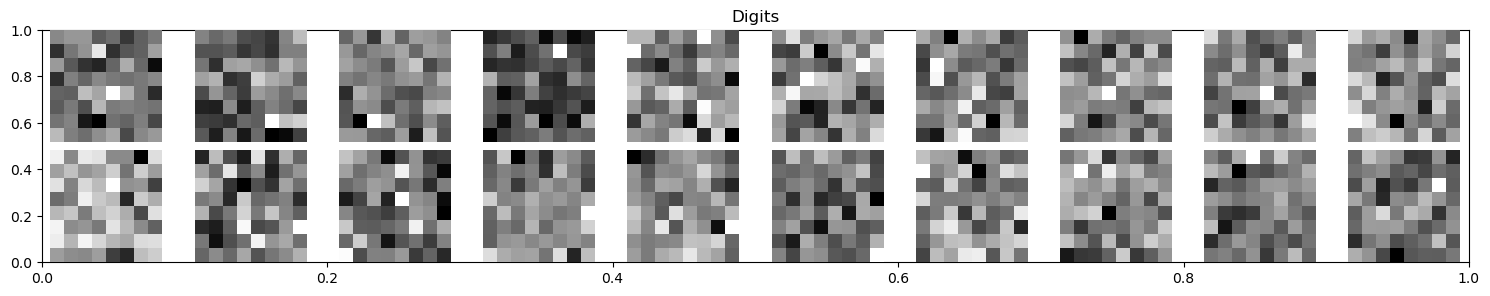

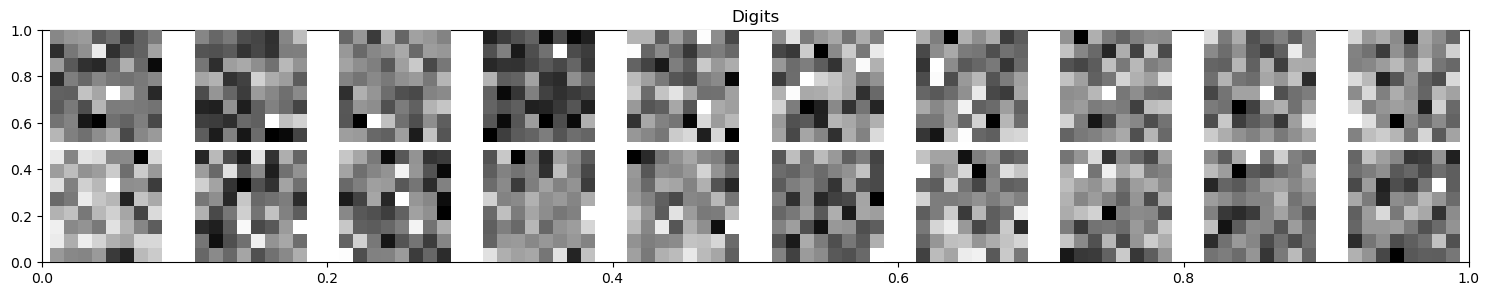

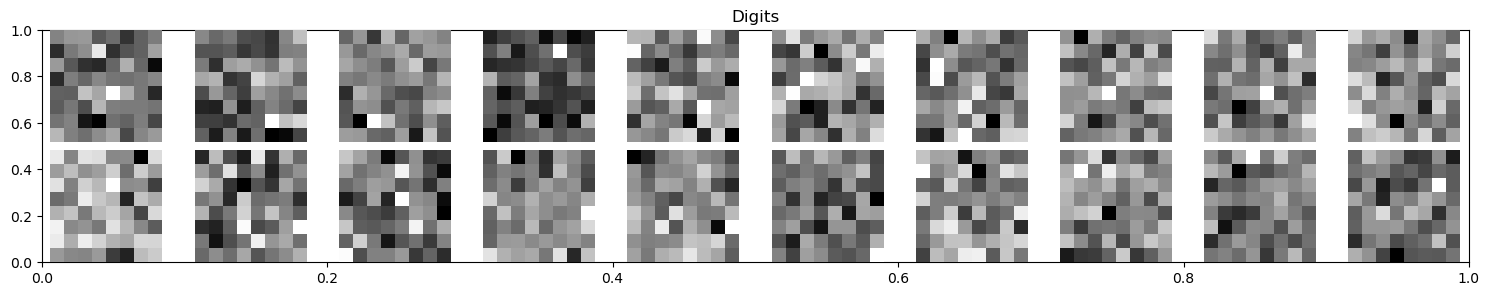

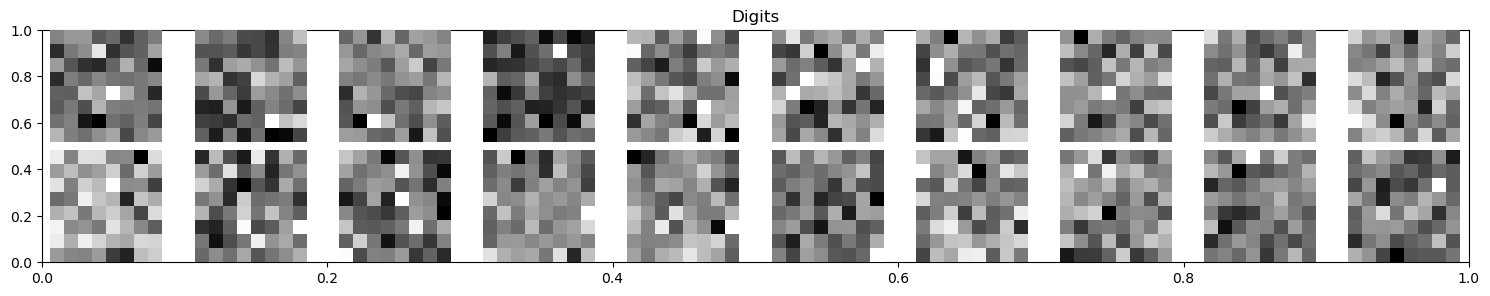

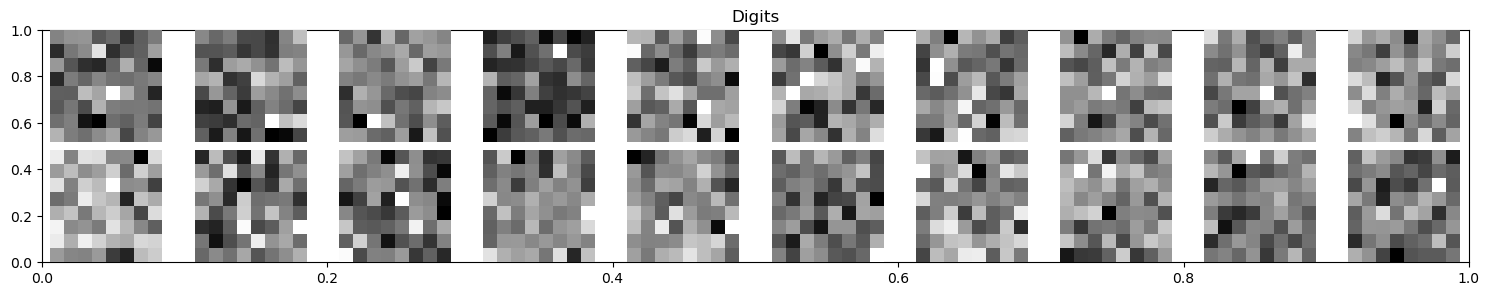

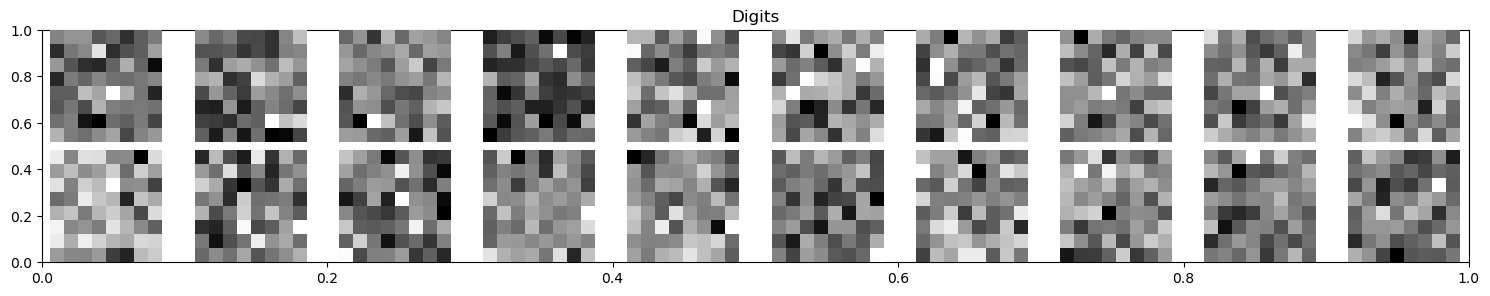

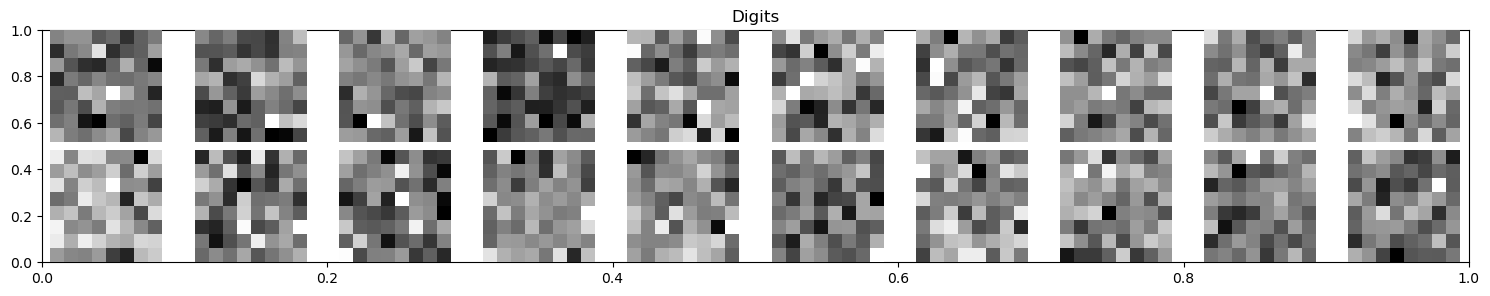

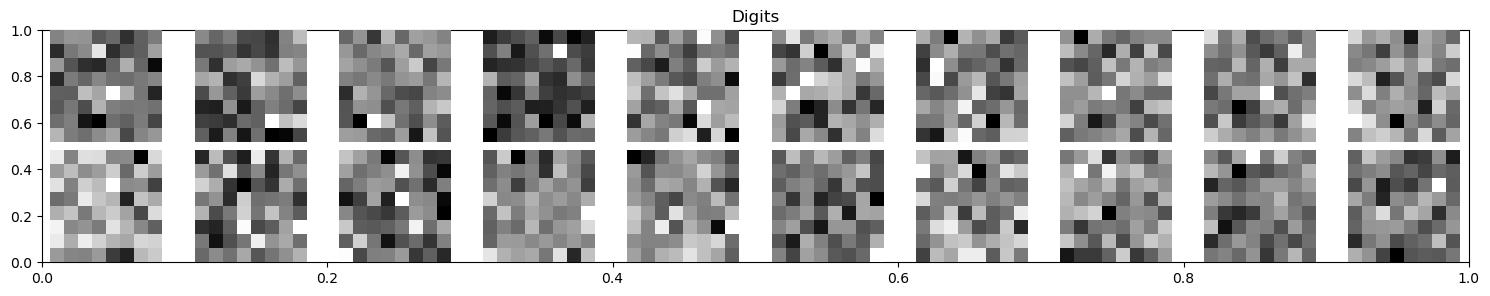

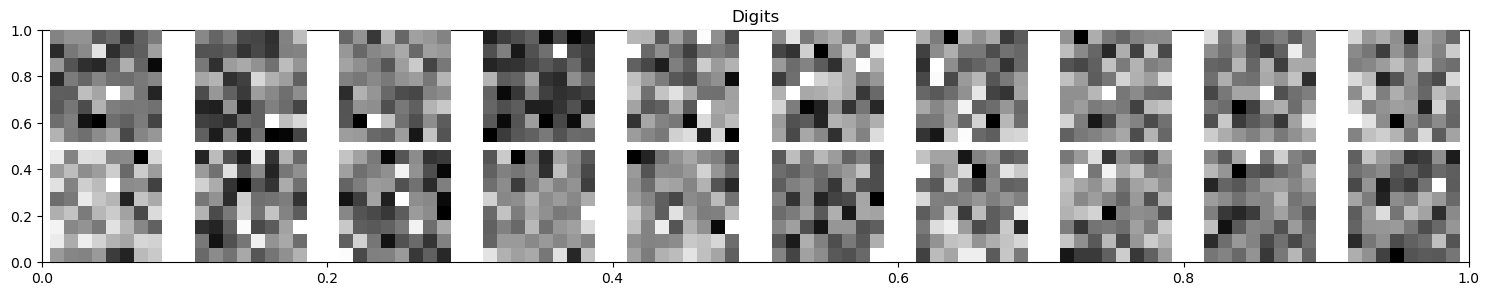

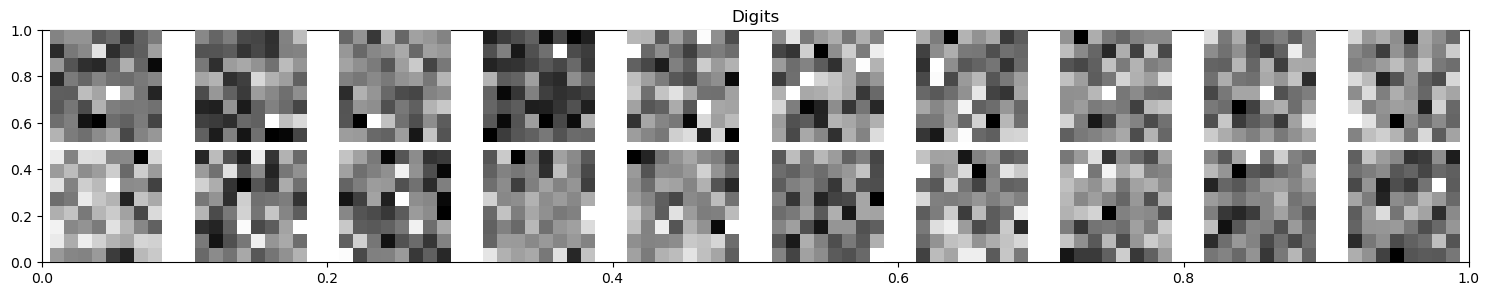

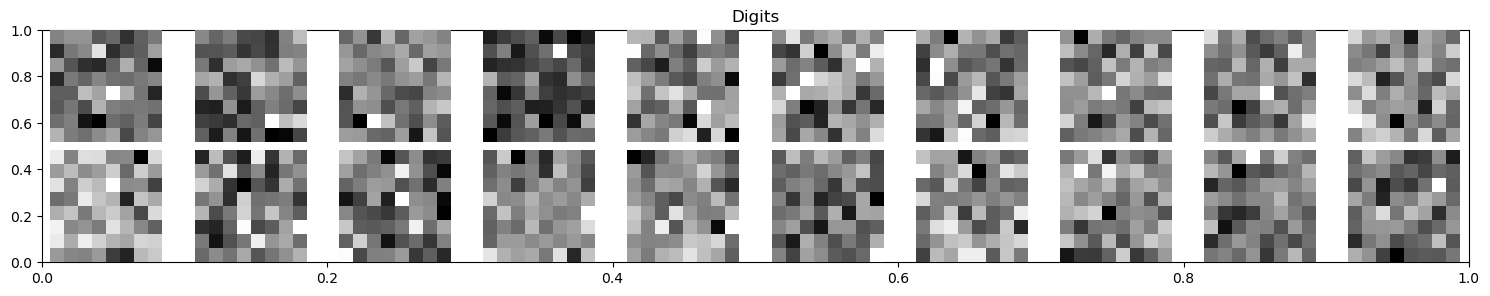

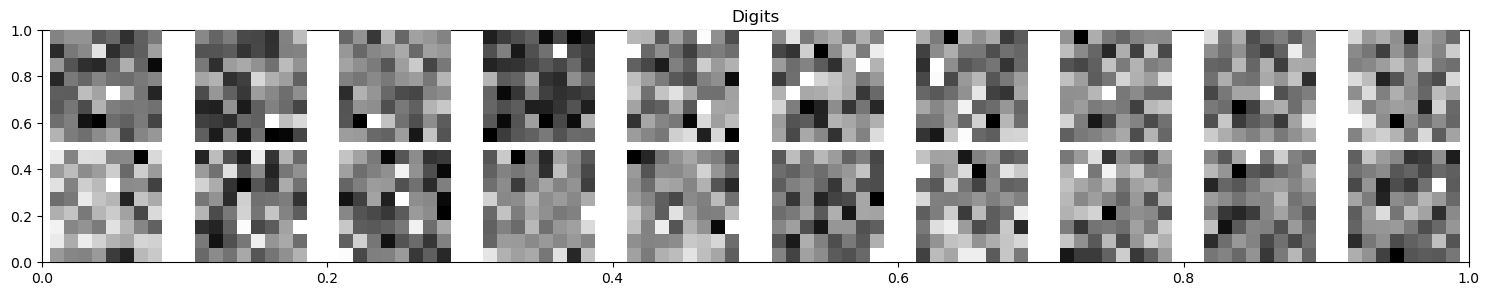

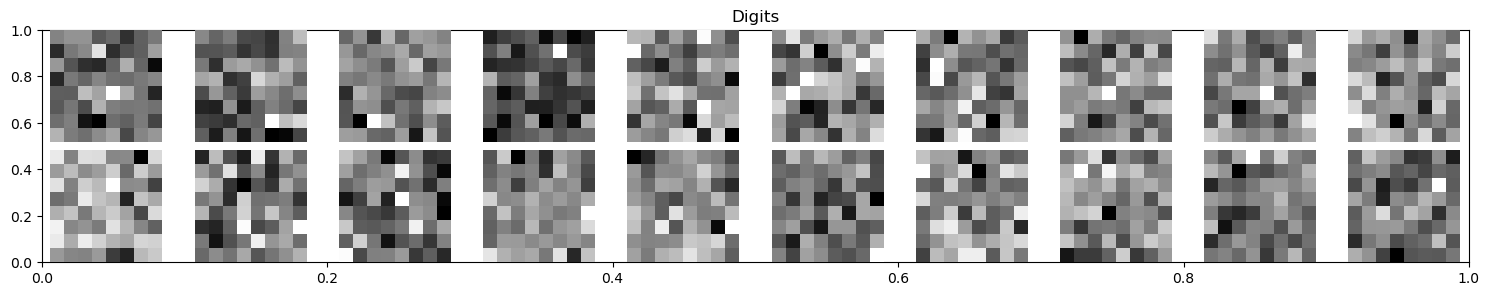

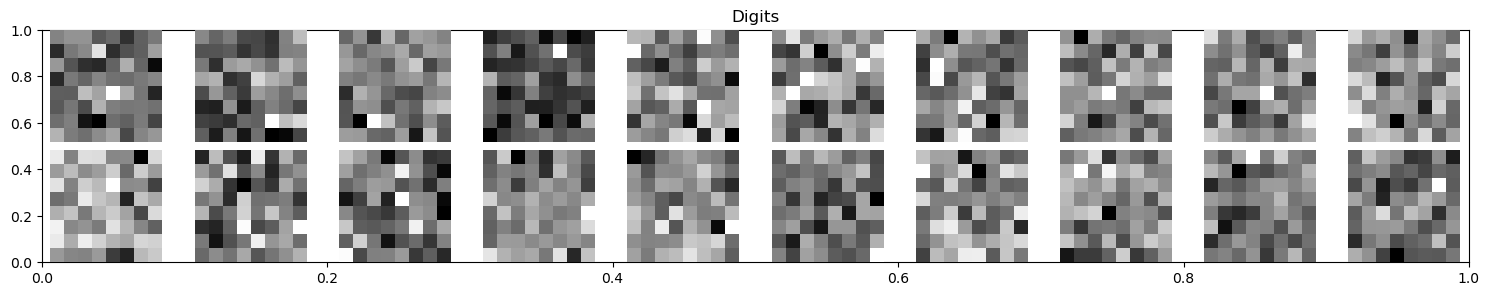

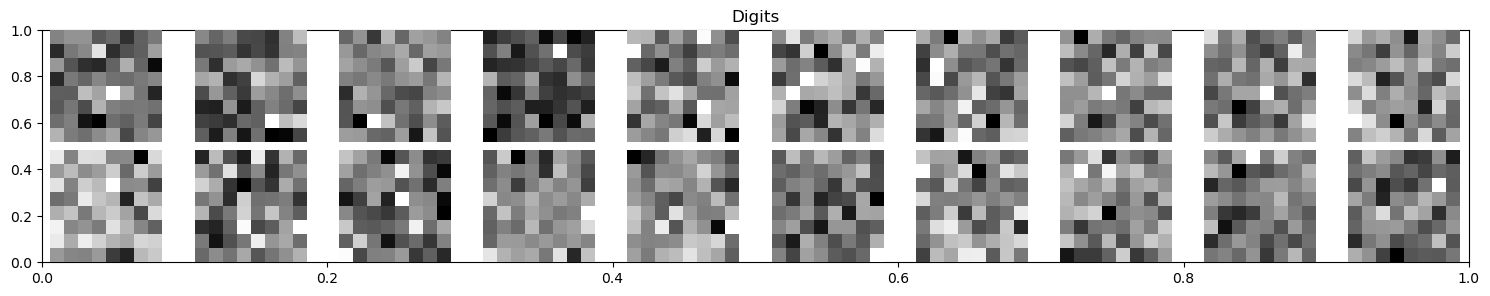

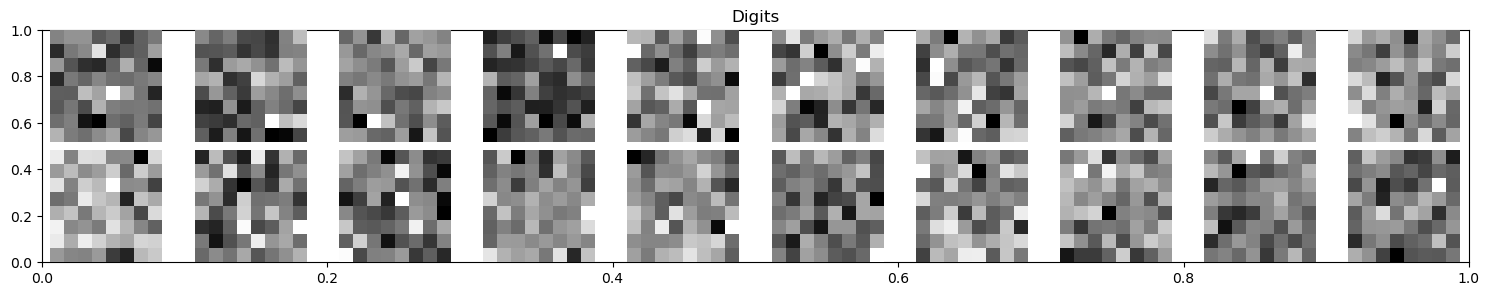

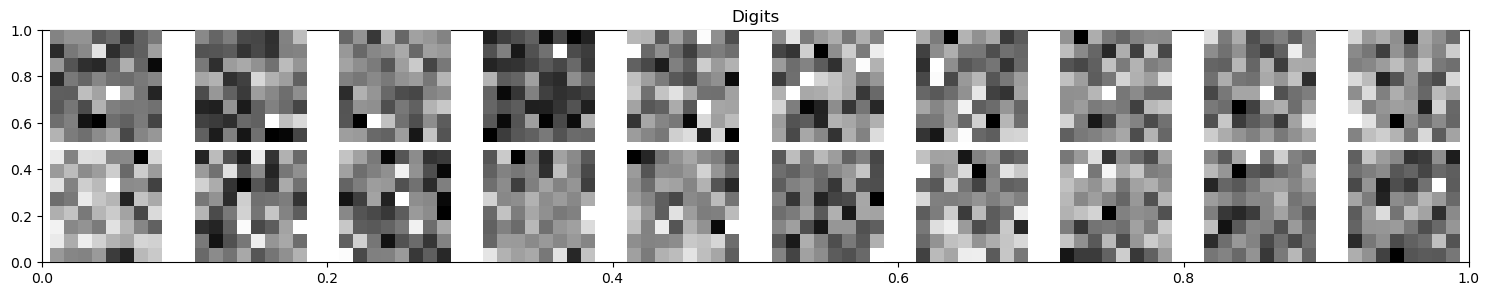

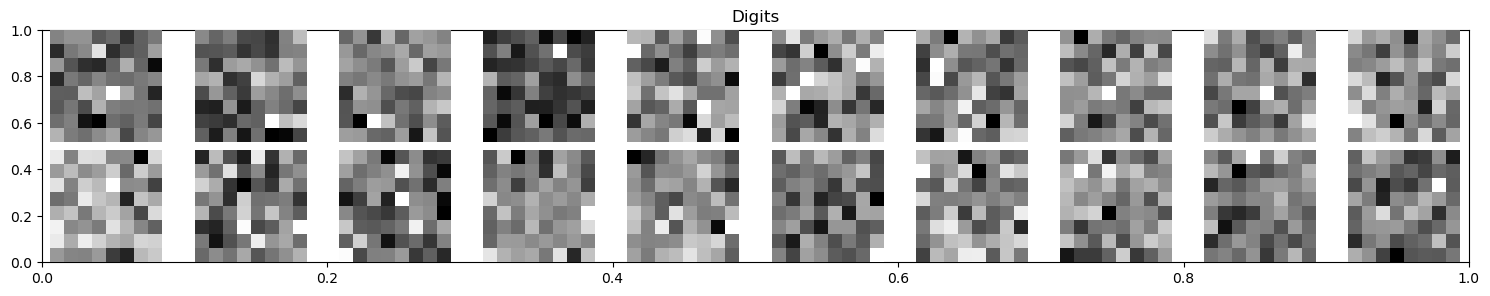

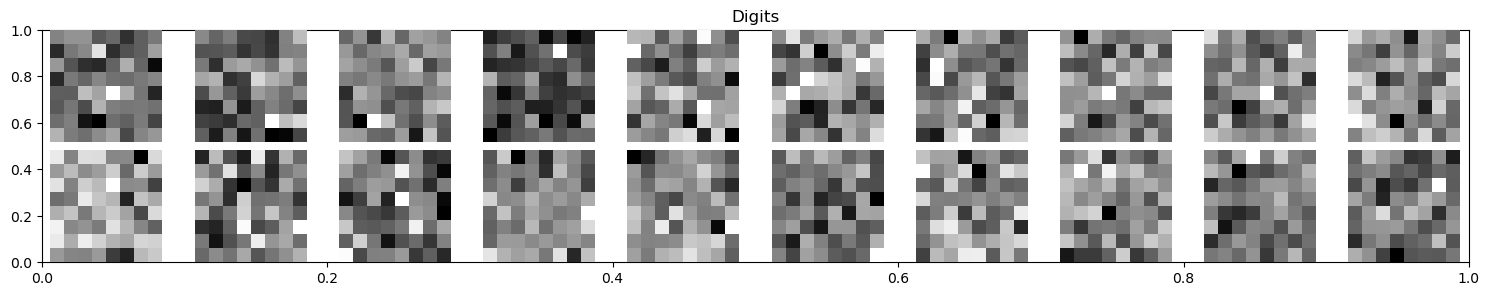

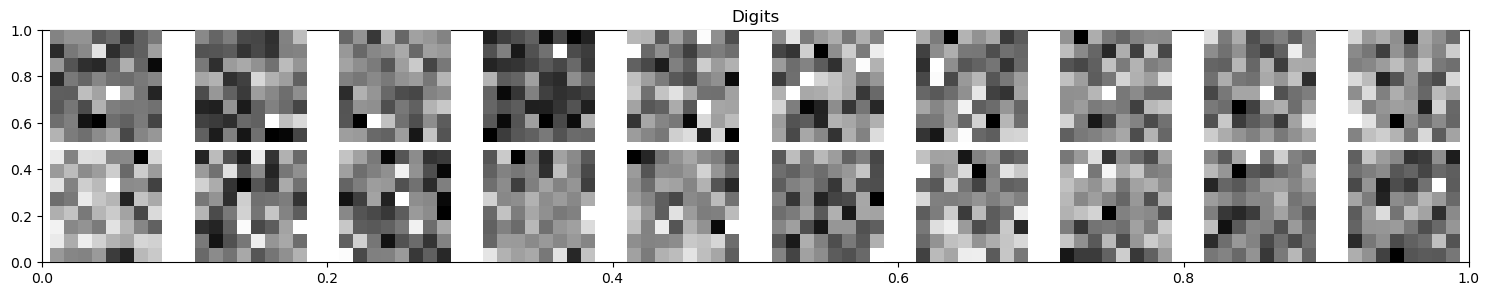

In [37]:
import sys
sys.path.append("../..")
from datasets.mpl2gif import figures_to_gif


L = 20
T = 100
eps = 2e-5

sigmas = sigmas_geometric(torch.linspace(1,0,L), sigma_min, sigma_max, var_schedule)
ncsm = torch.load("ncsm.ckpt", map_location="cuda:0")
ncsm.eval()

# dim=2
# num_samples = 1024
# x = torch.randn(size=(num_samples,2), device=device)
dim=(1,8,8)
num_samples = 20
x = torch.randn(size=(num_samples,*dim), device=device)
# x = x * sigma_max
x_change = torch.zeros_like(x)

figures = []

with torch.no_grad():
    
    for noise_level in range(0,L):
        
        alpha_i = eps * sigmas[noise_level]**2 / sigmas[0]**2
        
        for t in range(0,T):
            z_t = torch.randn(size=(num_samples,*dim), device=device)
            sigma_i = torch.ones(size=([num_samples]+[1]*len(dim)), device=device)*sigmas[noise_level] 
            x = x + alpha_i/2 * ncsm(x, sigma_i) + torch.sqrt(alpha_i) * z_t
            x_change += alpha_i/2 * ncsm(x, sigma_i) + torch.sqrt(alpha_i) * z_t
        

        figures.append(plot_digits(x))
        # plot.close()
        # figures.append(plot_digits(x))


    figures_to_gif(figures)


        # plt.figure()
        # plt.scatter(*(x.T.cpu()), s=5, alpha=0.5) #  cmap=cmap_orange_red, 
        # plt.axis('equal')
        # plt.show()
        # plt.close()